In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('Student_Performance.csv')

In [3]:
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [5]:
x=df.drop(columns='Performance Index')
y=df['Performance Index']

In [6]:
num_cols=x.select_dtypes(include='number').columns
num_cols

Index(['Hours Studied', 'Previous Scores', 'Sleep Hours',
       'Sample Question Papers Practiced'],
      dtype='object')

In [7]:
obj_cols=x.select_dtypes(include='object').columns
obj_cols

Index(['Extracurricular Activities'], dtype='object')

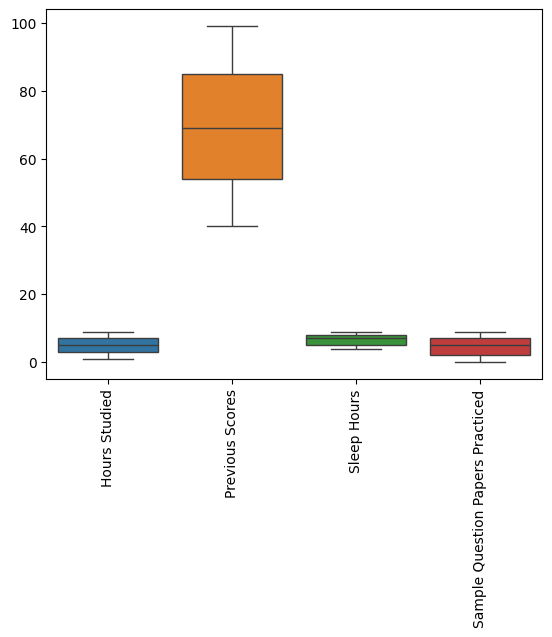

In [8]:
sns.boxplot(x[num_cols])
plt.xticks(rotation=90)
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

In [10]:
from sklearn.preprocessing import MinMaxScaler
scale=MinMaxScaler()
xtrain[num_cols]=scale.fit_transform(xtrain[num_cols])
xtrain

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
9254,0.500,0.152542,No,0.6,0.555556
1561,0.125,0.135593,Yes,0.6,0.666667
1670,0.125,0.694915,No,0.6,0.222222
6087,0.125,0.101695,No,0.4,0.111111
6669,0.875,0.118644,No,1.0,0.000000
...,...,...,...,...,...
5734,0.875,0.169492,Yes,0.4,0.666667
5191,0.375,0.474576,No,1.0,0.333333
5390,1.000,0.135593,No,0.6,0.666667
860,0.000,0.118644,No,1.0,0.000000


In [11]:
df.corr(numeric_only=True)

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.012390,0.001245,0.017463,0.373730
Previous Scores,-0.012390,1.000000,0.005944,0.007888,0.915189
Sleep Hours,0.001245,0.005944,1.000000,0.003990,0.048106
Sample Question Papers Practiced,0.017463,0.007888,0.003990,1.000000,0.043268
Performance Index,0.373730,0.915189,0.048106,0.043268,1.000000


In [12]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
# lencode=LabelEncoder()
# xtrain['Extracurricular Activities']=lencode.fit_transform(xtrain['Extracurricular Activities'])
# xtrain

In [13]:
oencoder=OneHotEncoder(sparse_output=False, handle_unknown='ignore')
values=oencoder.fit_transform(xtrain[obj_cols])
cols=oencoder.get_feature_names_out()

In [14]:
xtrain[cols]=values

In [15]:
xtrain.drop(columns='Extracurricular Activities',inplace=True)

In [16]:
xtrain

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Extracurricular Activities_No,Extracurricular Activities_Yes
9254,0.500,0.152542,0.6,0.555556,1.0,0.0
1561,0.125,0.135593,0.6,0.666667,0.0,1.0
1670,0.125,0.694915,0.6,0.222222,1.0,0.0
6087,0.125,0.101695,0.4,0.111111,1.0,0.0
6669,0.875,0.118644,1.0,0.000000,1.0,0.0
...,...,...,...,...,...,...
5734,0.875,0.169492,0.4,0.666667,0.0,1.0
5191,0.375,0.474576,1.0,0.333333,1.0,0.0
5390,1.000,0.135593,0.6,0.666667,1.0,0.0
860,0.000,0.118644,1.0,0.000000,1.0,0.0


In [17]:
xtest[num_cols]=scale.transform(xtest[num_cols])
val=oencoder.transform(xtest[obj_cols])
col=oencoder.get_feature_names_out()

In [18]:
xtest[col]=val

In [19]:
xtest.drop(columns='Extracurricular Activities',inplace=True)

In [20]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()

In [21]:
model.fit(xtrain,ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

In [23]:
ypred_train=model.predict(xtrain)

In [24]:
print('Train R2 SCORE: ',model.score(xtrain,ytrain))
print('Train MAE: ', mean_absolute_error(ytrain,ypred_train))
print('Train RMSE: ', root_mean_squared_error(ytrain,ypred_train))

Train R2 SCORE:  0.9886898790682355
Train MAE:  1.6193054830334277
Train RMSE:  2.0419931071198567


In [25]:
ypred_test=model.predict(xtest)

In [26]:
print('Test R2 SCORE: ', model.score(xtest,ytest))
print('TEST MAE: ', mean_absolute_error(ytest,ypred_test))
print('TEST RMSE: ', root_mean_squared_error(ytest,ypred_test))

Test R2 SCORE:  0.9889832909573145
TEST MAE:  1.611121346312304
TEST RMSE:  2.020551508505006
